In [1]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV ,StratifiedKFold, cross_val_score
from scipy.stats import uniform, randint
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
train = pd.read_csv('/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/EDA/featured_dataset/train_featured.csv')
val   = pd.read_csv('/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/EDA/featured_dataset/val_featured.csv')
test  = pd.read_csv('/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/EDA/featured_dataset/test_featured.csv')

print(f"Train      : {train.shape}")
print(f"Validation : {val.shape}")
print(f"Test       : {test.shape}")

Train      : (27499, 37)
Validation : (2749, 37)
Test       : (4318, 33)


## Create Target Variables

In [4]:
# 0 = Not Cancelled, 1 = Cancelled, 2 = No-Show
for df in [train, val]:
    df['Cancelled'] = (df['Reservation_Status'] == 'Cancelled').astype(int)
    df['No_Show']   = (df['Reservation_Status'] == 'No-Show').astype(int)
    df['Target']    = np.where(df['Reservation_Status'] == 'Cancelled', 1,
                      np.where(df['Reservation_Status'] == 'No-Show', 2, 0))

labels = {0: 'Not Cancelled', 1: 'Cancelled', 2: 'No-Show'}

print("=== Class Distribution — Train ===")
for cls, count in train['Target'].value_counts().sort_index().items():
    print(f"  {cls} ({labels[cls]:<15}) : {count}  ({count/len(train)*100:.1f}%)")

print("\n=== Class Distribution — Validation ===")
for cls, count in val['Target'].value_counts().sort_index().items():
    print(f"  {cls} ({labels[cls]:<15}) : {count}  ({count/len(val)*100:.1f}%)")

=== Class Distribution — Train ===
  0 (Not Cancelled  ) : 21240  (77.2%)
  1 (Cancelled      ) : 4134  (15.0%)
  2 (No-Show        ) : 2125  (7.7%)

=== Class Distribution — Validation ===
  0 (Not Cancelled  ) : 1610  (58.6%)
  1 (Cancelled      ) : 741  (27.0%)
  2 (No-Show        ) : 398  (14.5%)


## Extract data featuers from all 3 datasets

In [5]:
date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']

for df in [train, val, test]:
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['Lead_Time']        = (df['Expected_checkin'] - df['Booking_date']).dt.days
    df['Length_of_Stay']   = (df['Expected_checkout'] - df['Expected_checkin']).dt.days
    df['Length_of_Stay']   = df['Length_of_Stay'].clip(lower=1)
    df['Booking_Month']    = df['Booking_date'].dt.month
    df['Checkin_Month']    = df['Expected_checkin'].dt.month
    df['Checkin_DayOfWeek']= df['Expected_checkin'].dt.dayofweek

# Drop date and status columns
drop_cols = ['Reservation_Status', 'Expected_checkin', 'Expected_checkout', 'Booking_date']
train = train.drop(columns=drop_cols, errors='ignore')
val   = val.drop(columns=drop_cols, errors='ignore')
test  = test.drop(columns=drop_cols, errors='ignore')

print("Date features extracted and date columns dropped")
print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")

Date features extracted and date columns dropped
Train shape : (27499, 35)
Test shape  : (4318, 31)


## Feature engineering

In [6]:
median_rate = train['Room_Rate'].median()

for df in [train, val, test]:
    df['Total_Guests']       = df['Adults'] + df['Children'] + df['Babies']
    df['Has_Discount']       = (df['Discount_Rate'] > 0).astype(int)
    df['High_Room_Rate']     = (df['Room_Rate'] > median_rate).astype(int)
    df['Long_Lead_Time']     = (df['Lead_Time'] > 90).astype(int)
    df['Short_Stay']         = (df['Length_of_Stay'] == 1).astype(int)
    df['Weekend_Checkin']    = (df['Checkin_DayOfWeek'] >= 5).astype(int)
    df['Peak_Season']        = df['Checkin_Month'].isin([6, 7, 8]).astype(int)
    # Previous cancellations — Yes/No string so compare as string
    df['Has_Cancelled_Before'] = (df['Previous_Cancellations'] == 'Yes').astype(int)

print("Feature engineering complete")
print(f"Train shape : {train.shape}")

Feature engineering complete
Train shape : (27499, 42)


## Encoding Categorical columns

In [7]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
# Remove target-related cols if still present
cat_cols = [c for c in cat_cols if c not in ['Cancelled', 'No_Show', 'Target']]
print("Columns being encoded:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined train + val + test to avoid unseen category errors
    combined = pd.concat([train[col], val[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    val[col]   = le.transform(val[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    encoders[col] = le

print("Encoding complete")

Columns being encoded: ['Gender', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region', 'Hotel_Type', 'Meal_Type', 'Visted_Previously', 'Previous_Cancellations', 'Deposit_type', 'Booking_channel', 'Required_Car_Parking', 'Use_Promotion']
Encoding complete


## Split featuers and targets

In [8]:
drop_target = ['Cancelled', 'No_Show', 'Target', 'Reservation-id', 'Reservation_Status_Code']

X_train = train.drop(columns=[c for c in drop_target if c in train.columns])
y_train = train['Target']

X_val = val.drop(columns=[c for c in drop_target if c in val.columns])
y_val = val['Target']

# Test doesn't have Reservation_Status_Code so this handles it safely
X_test = test[[c for c in X_train.columns if c in test.columns]]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

# Verify columns match
print(f"\nColumns in X_train but not X_test: {set(X_train.columns) - set(X_test.columns)}")
print(f"Columns in X_test but not X_train: {set(X_test.columns) - set(X_train.columns)}")

X_train : (27499, 37)
X_val   : (2749, 37)
X_test  : (4318, 37)

Columns in X_train but not X_test: set()
Columns in X_test but not X_train: set()


## Scale Features

In [9]:
scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete — fitted on train only")

Scaling complete — fitted on train only


## SMOTE to handle class imbalance

In [10]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution BEFORE SMOTE:")
for cls, count in pd.Series(y_train).value_counts().sort_index().items():
    print(f"  {labels[cls]:<15} : {count}")

print("\nClass distribution AFTER SMOTE:")
for cls, count in pd.Series(y_train_sm).value_counts().sort_index().items():
    print(f"  {labels[cls]:<15} : {count}")

Class distribution BEFORE SMOTE:
  Not Cancelled   : 21240
  Cancelled       : 4134
  No-Show         : 2125

Class distribution AFTER SMOTE:
  Not Cancelled   : 21240
  Cancelled       : 21240
  No-Show         : 21240


##  Class weights and cross validation setup

In [11]:
classes      = np.array([0, 1, 2])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("\nStratifiedKFold with 5 splits ready")

Class weights: {np.int64(0): np.float64(0.4315599497802888), np.int64(1): np.float64(2.217303660699887), np.int64(2): np.float64(4.31356862745098)}

StratifiedKFold with 5 splits ready


## Evaluation helper function

In [12]:
CLASS_NAMES = ['Not Cancelled', 'Cancelled', 'No-Show']

def evaluate_model(name, model, X, y, color='Blues'):
    preds = model.predict(X)
    probs = model.predict_proba(X)

    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds, average='weighted', zero_division=0)
    rec  = recall_score(y, preds, average='weighted', zero_division=0)
    f1   = f1_score(y, preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(y, probs, multi_class='ovr', average='weighted')
    except:
        auc = float('nan')

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}  <- primary metric")
    print(f"  F1 Score  : {f1:.4f}  <- secondary metric")
    print(f"  ROC AUC   : {auc:.4f}")
    print()
    print(classification_report(y, preds, target_names=CLASS_NAMES))

    cm = confusion_matrix(y, preds)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1 Score': round(f1,4), 'ROC AUC': round(auc,4)}

print("Evaluation function ready")

Evaluation function ready


## Logistic Regression - Base and Tuned


  Logistic Regression (Base)
  Accuracy  : 0.3740
  Precision : 0.4437
  Recall    : 0.3740  <- primary metric
  F1 Score  : 0.3902  <- secondary metric
  ROC AUC   : 0.5133

               precision    recall  f1-score   support

Not Cancelled       0.60      0.48      0.53      1610
    Cancelled       0.27      0.13      0.18       741
      No-Show       0.15      0.40      0.21       398

     accuracy                           0.37      2749
    macro avg       0.34      0.34      0.31      2749
 weighted avg       0.44      0.37      0.39      2749



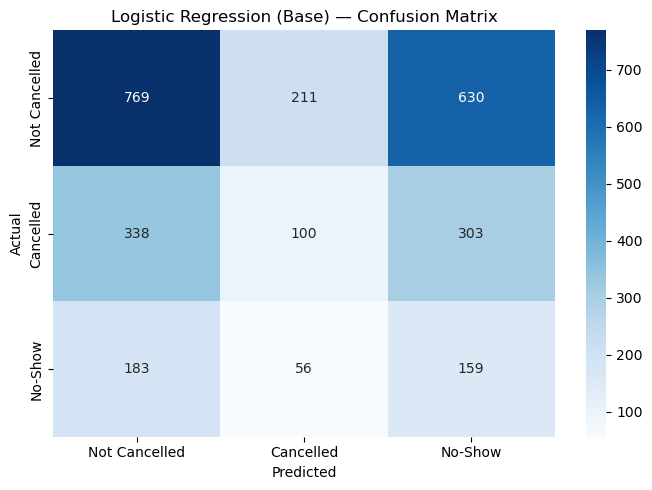

Best LR params: {'C': np.float64(59.86684841970366), 'solver': 'lbfgs'}

  Logistic Regression (Tuned)
  Accuracy  : 0.3740
  Precision : 0.4437
  Recall    : 0.3740  <- primary metric
  F1 Score  : 0.3902  <- secondary metric
  ROC AUC   : 0.5133

               precision    recall  f1-score   support

Not Cancelled       0.60      0.48      0.53      1610
    Cancelled       0.27      0.13      0.18       741
      No-Show       0.15      0.40      0.21       398

     accuracy                           0.37      2749
    macro avg       0.34      0.34      0.31      2749
 weighted avg       0.44      0.37      0.39      2749



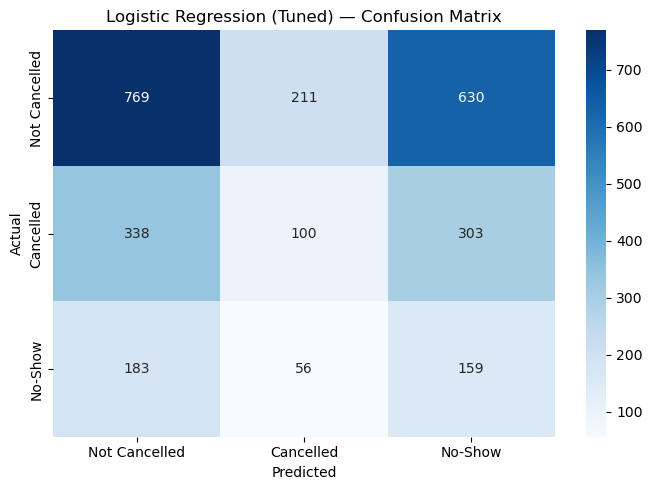

In [13]:
# Base
lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_base.fit(X_train_sm, y_train_sm)
lr_base_results = evaluate_model('Logistic Regression (Base)', lr_base, X_val_scaled, y_val, 'Blues')

# Tuned
lr_random = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    {'C': uniform(0.001, 100), 'solver': ['lbfgs', 'liblinear']},
    n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
lr_random.fit(X_train_sm, y_train_sm)
print("Best LR params:", lr_random.best_params_)
lr_tuned = lr_random.best_estimator_
lr_tuned_results = evaluate_model('Logistic Regression (Tuned)', lr_tuned, X_val_scaled, y_val, 'Blues')

## XGBoost - Based and Tuned


  XGBoost (Base)
  Accuracy  : 0.5838
  Precision : 0.4736
  Recall    : 0.5838  <- primary metric
  F1 Score  : 0.4387  <- secondary metric
  ROC AUC   : 0.5212

               precision    recall  f1-score   support

Not Cancelled       0.59      0.99      0.74      1610
    Cancelled       0.35      0.01      0.02       741
      No-Show       0.25      0.01      0.01       398

     accuracy                           0.58      2749
    macro avg       0.39      0.34      0.26      2749
 weighted avg       0.47      0.58      0.44      2749



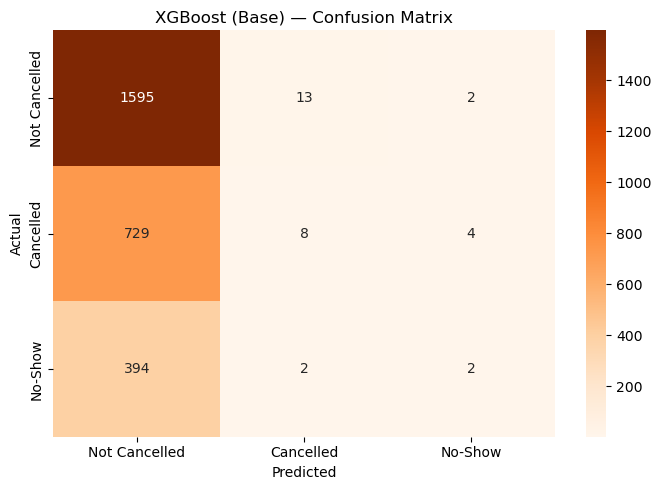

Best XGB params: {'colsample_bylevel': np.float64(0.842571623863836), 'colsample_bytree': np.float64(0.6036788206466518), 'gamma': np.float64(0.05073577143301605), 'learning_rate': np.float64(0.14270035382161117), 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 583, 'reg_alpha': np.float64(0.30536386034439345), 'reg_lambda': np.float64(1.4712275071724532), 'subsample': np.float64(0.8345272428958741)}
Best iteration: 483

  XGBoost (Tuned)
  Accuracy  : 0.5791
  Precision : 0.4427
  Recall    : 0.5791  <- primary metric
  F1 Score  : 0.4394  <- secondary metric
  ROC AUC   : 0.5196

               precision    recall  f1-score   support

Not Cancelled       0.59      0.98      0.73      1610
    Cancelled       0.31      0.02      0.04       741
      No-Show       0.11      0.00      0.00       398

     accuracy                           0.58      2749
    macro avg       0.34      0.33      0.26      2749
 weighted avg       0.44      0.58      0.44      2749



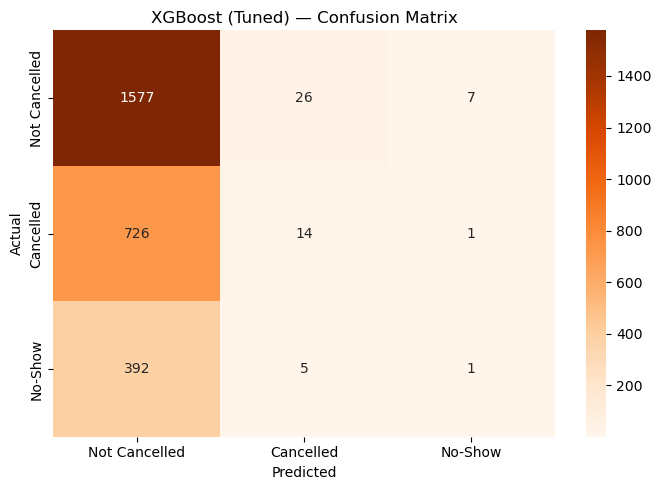

In [23]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split

# ── Base model (keep as-is) ──────────────────────────────────
xgb_base = XGBClassifier(
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=42, verbosity=0
)
xgb_base.fit(X_train_sm, y_train_sm)
xgb_base_results = evaluate_model('XGBoost (Base)', xgb_base, X_val_scaled, y_val, 'Oranges')

# ── Step 1: Bigger RandomizedSearchCV ────────────────────────
xgb_random = RandomizedSearchCV(
    XGBClassifier(objective='multi:softprob', num_class=3,
                  eval_metric='mlogloss', random_state=42, verbosity=0,
                  tree_method='hist', device='cpu'),
    {
        'n_estimators'      : randint(200, 600),
        'max_depth'         : randint(4, 10),
        'learning_rate'     : uniform(0.01, 0.2),
        'subsample'         : uniform(0.7, 0.3),
        'colsample_bytree'  : uniform(0.6, 0.4),
        'colsample_bylevel' : uniform(0.6, 0.4),
        'min_child_weight'  : randint(1, 10),
        'gamma'             : uniform(0, 0.5),
        'reg_alpha'         : uniform(0, 1.0),
        'reg_lambda'        : uniform(0.5, 2.0),
    },
    n_iter=40, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)

# ── Step 2: Sample weights ────────────────────────────────────
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_sm)
xgb_random.fit(X_train_sm, y_train_sm, sample_weight=sample_weights)
print("Best XGB params:", xgb_random.best_params_)

# ── Step 3: Early stopping on final model ─────────────────────
X_tr, X_es, y_tr, y_es = train_test_split(
    X_train_sm, y_train_sm, test_size=0.1, random_state=42, stratify=y_train_sm
)

best_params = {k: v for k, v in xgb_random.best_params_.items() if k != 'n_estimators'}

xgb_tuned = XGBClassifier(
    **best_params,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0,
    tree_method='hist',
    device='cpu',
    early_stopping_rounds=20,
    n_estimators=1000  # early stopping will find the best one within 1000
)

xgb_tuned.fit(
    X_tr, y_tr,
    eval_set=[(X_es, y_es)],
    verbose=False
)

print(f"Best iteration: {xgb_tuned.best_iteration}")
xgb_tuned_results = evaluate_model('XGBoost (Tuned)', xgb_tuned, X_val_scaled, y_val, 'Oranges')

## Decision Tree - Based and Tuned 

Decision Tree Base — Cross Validation Scores:
  F1 per fold : [0.7049 0.7027 0.704 ]
  Mean F1     : 0.7039
  Std         : 0.0009

  Decision Tree (Base)
  Accuracy  : 0.4820
  Precision : 0.4501
  Recall    : 0.4820  <- primary metric
  F1 Score  : 0.4622  <- secondary metric
  ROC AUC   : 0.5137

               precision    recall  f1-score   support

Not Cancelled       0.60      0.69      0.64      1610
    Cancelled       0.29      0.21      0.24       741
      No-Show       0.15      0.13      0.14       398

     accuracy                           0.48      2749
    macro avg       0.35      0.34      0.34      2749
 weighted avg       0.45      0.48      0.46      2749



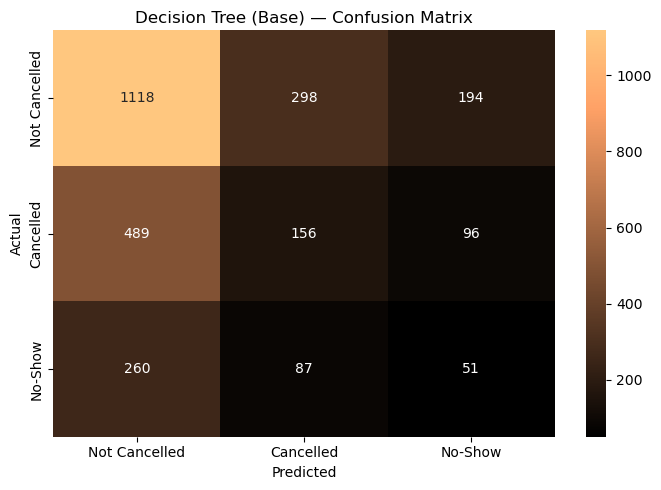

In [16]:
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# DECISION TREE — BASE MODEL (No Tuning)
# class_weight='balanced' handles class imbalance
# ============================================================
dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
dt_base.fit(X_train_sm, y_train_sm)

print("Decision Tree Base — Cross Validation Scores:")
cv_scores = cross_val_score(dt_base, X_train_sm, y_train_sm,
                            cv=cv, scoring='f1_weighted')
print(f"  F1 per fold : {cv_scores.round(4)}")
print(f"  Mean F1     : {cv_scores.mean():.4f}")
print(f"  Std         : {cv_scores.std():.4f}")

dt_base_results = evaluate_model(
    'Decision Tree (Base)', dt_base, X_val_scaled, y_val, color='copper'
)

Best DT params: {'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 4}

  Decision Tree (Tuned)
  Accuracy  : 0.5118
  Precision : 0.4542
  Recall    : 0.5118  <- primary metric
  F1 Score  : 0.4698  <- secondary metric
  ROC AUC   : 0.5187

               precision    recall  f1-score   support

Not Cancelled       0.60      0.78      0.68      1610
    Cancelled       0.30      0.15      0.20       741
      No-Show       0.16      0.11      0.13       398

     accuracy                           0.51      2749
    macro avg       0.35      0.35      0.34      2749
 weighted avg       0.45      0.51      0.47      2749



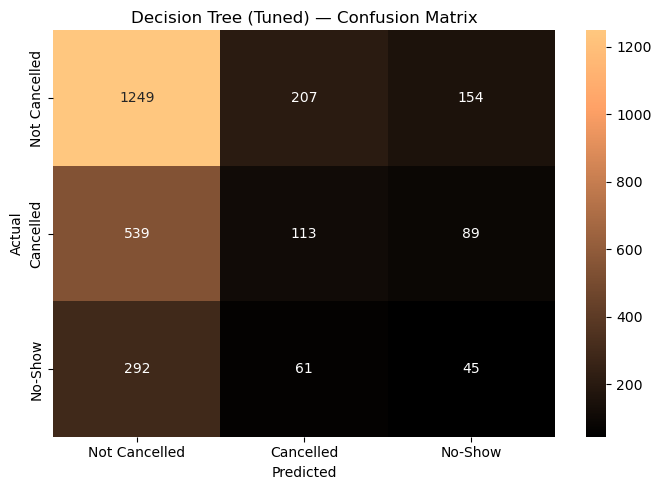

In [34]:
# ============================================================
# DECISION TREE — TUNED (GridSearchCV)
# max_depth controls overfitting
# criterion: gini vs entropy — two ways to measure split quality
# min_samples_split: minimum samples needed to split a node
# ============================================================
dt_params = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    {'max_depth': randint(3, 20), 'min_samples_split': randint(2, 10),
     'criterion': ['gini', 'entropy']},
    n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
dt_random.fit(X_train_sm, y_train_sm)
print("Best DT params:", dt_random.best_params_)
dt_tuned = dt_random.best_estimator_
dt_tuned_results = evaluate_model('Decision Tree (Tuned)', dt_tuned, X_val_scaled, y_val, 'copper')

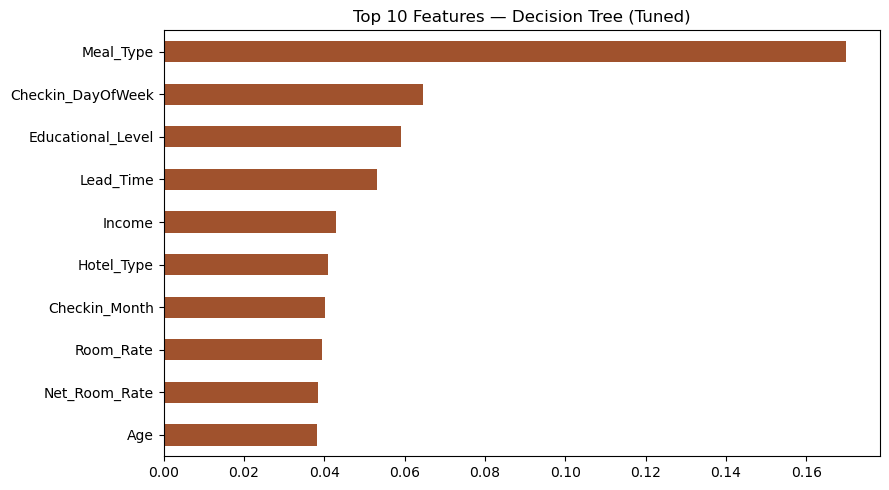

In [18]:
# ============================================================
# DECISION TREE — FEATURE IMPORTANCE
# Shows which features drive cancellation/no-show predictions
# Useful for client presentation
# ============================================================
feat_imp = pd.Series(dt_tuned.feature_importances_, index=X_train.columns)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.sort_values(ascending=False).head(10).plot(kind='barh', ax=ax, color='sienna')
ax.set_title("Top 10 Features — Decision Tree (Tuned)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Model Comparison

In [27]:
all_results = {
    'LR (Base)'  : lr_base_results,
    'LR (Tuned)' : lr_tuned_results,
    'XGB (Base)' : xgb_base_results,
    'XGB (Tuned)': xgb_tuned_results,
    'DT (Base)'  : dt_base_results,
    'DT (Tuned)' : dt_tuned_results,
}
results_df = pd.DataFrame(all_results).T

# Weighted scoring
weights = {'Recall': 0.35, 'F1 Score': 0.30, 'Precision': 0.20, 'ROC AUC': 0.10, 'Accuracy': 0.05}
results_df['Weighted Score'] = results_df.apply(
    lambda row: sum(row[m] * w for m, w in weights.items()), axis=1).round(4)

results_df = results_df.sort_values('Weighted Score', ascending=False)
print(results_df.to_string())

             Accuracy  Precision  Recall  F1 Score  ROC AUC  Weighted Score
XGB (Base)     0.5838     0.4736  0.5838    0.4387   0.5212          0.5120
XGB (Tuned)    0.5791     0.4427  0.5791    0.4394   0.5196          0.5040
DT (Tuned)     0.5118     0.4542  0.5118    0.4698   0.5187          0.4884
DT (Base)      0.4820     0.4501  0.4820    0.4622   0.5137          0.4728
LR (Base)      0.3740     0.4437  0.3740    0.3902   0.5133          0.4067
LR (Tuned)     0.3740     0.4437  0.3740    0.3902   0.5133          0.4067


## Comparison charts

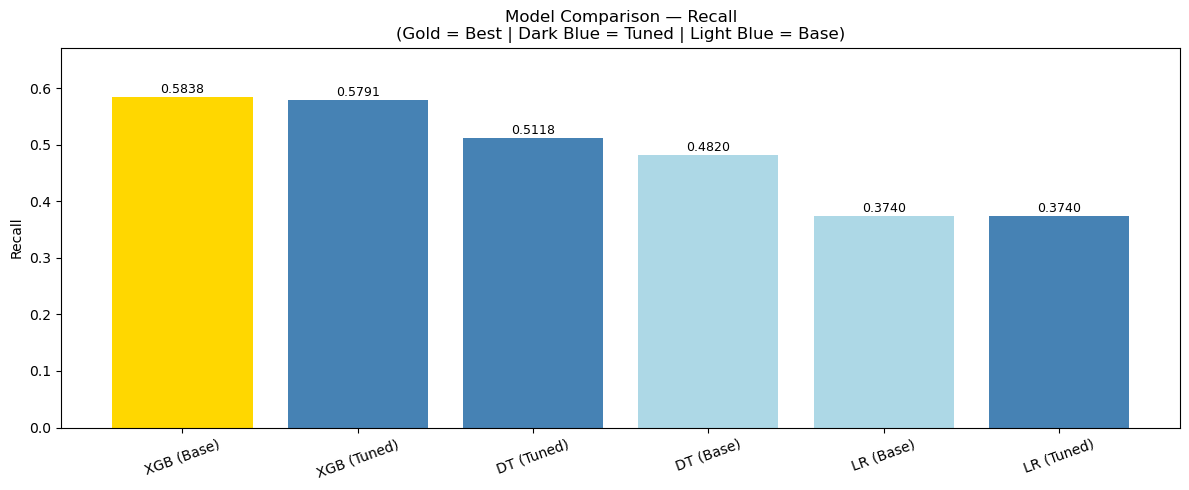

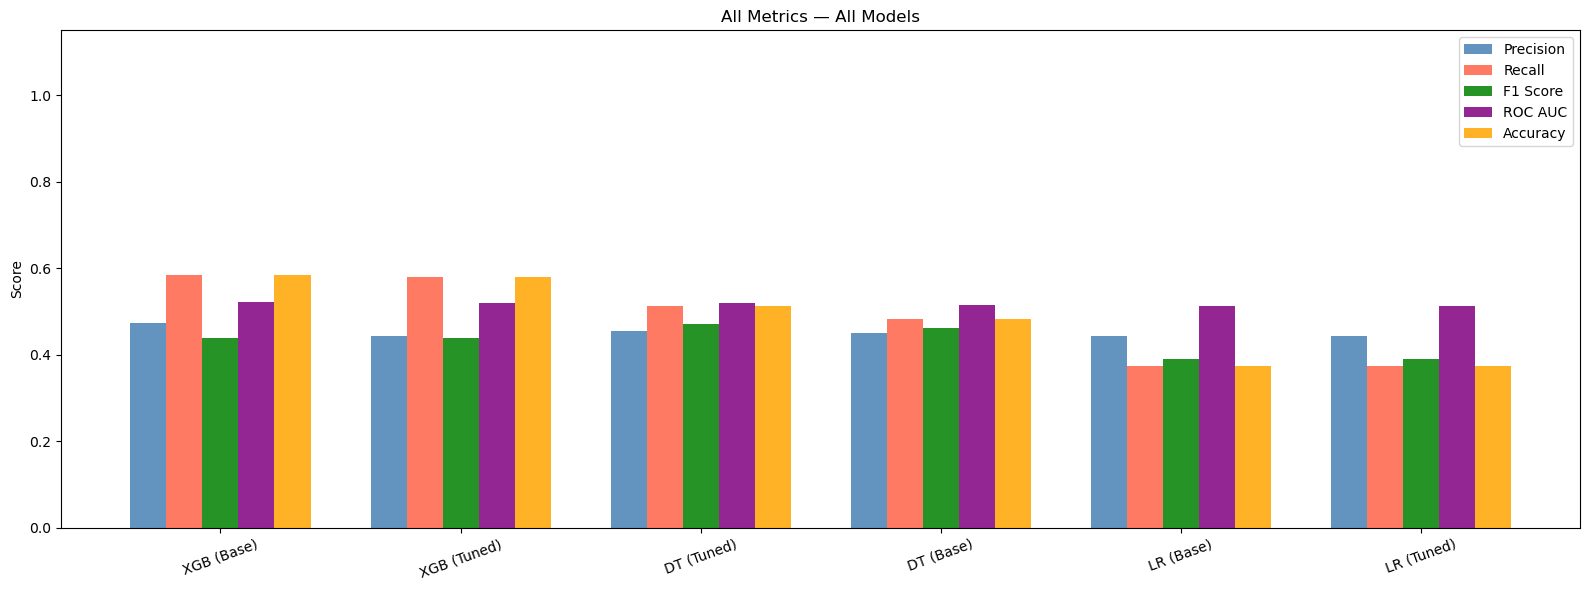

In [33]:
# Recall comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['gold' if i == 0 else 'steelblue' if 'Tuned' in n else 'lightblue'
          for i, n in enumerate(results_df.index)]
bars = ax.bar(results_df.index, results_df['Recall'], color=colors)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Recall')
ax.set_title('Model Comparison — Recall\n(Gold = Best | Dark Blue = Tuned | Light Blue = Base)')
ax.set_ylim(0, max(results_df['Recall']) * 1.15)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# All metrics side by side
metrics  = ['Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Accuracy']
colors_m = ['steelblue', 'tomato', 'green', 'purple', 'orange']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    bars = ax.bar(x + (i-2)*width, results_df[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=20)
ax.set_ylabel('Score')
ax.set_title('All Metrics — All Models')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

## Best model and test predictions

Best model: XGB (Base)
Accuracy          0.5838
Precision         0.4736
Recall            0.5838
F1 Score          0.4387
ROC AUC           0.5212
Weighted Score    0.5120
Name: XGB (Base), dtype: float64

=== Test Prediction Distribution ===
  Not Cancelled   : 4176  (96.7%)
  Cancelled       : 128  (3.0%)
  No-Show         : 14  (0.3%)


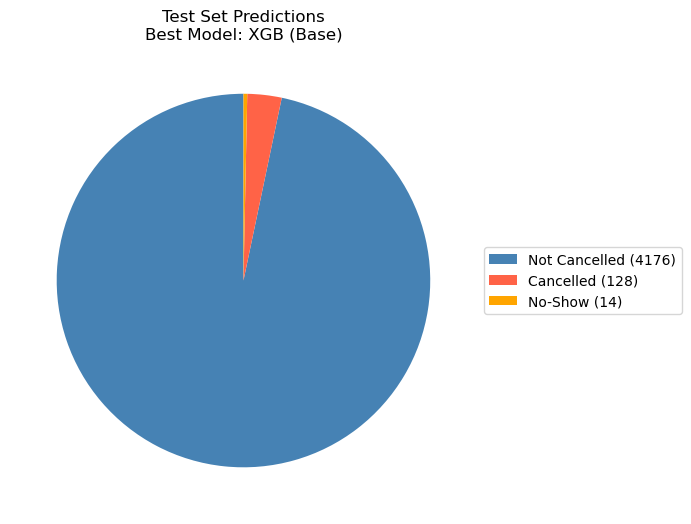

Predictions saved to predictions/test_predictions.csv


In [32]:
model_map = {
    'LR (Base)': lr_base, 'LR (Tuned)': lr_tuned,
    'RF (Base)': rf_base, 'RF (Tuned)': rf_tuned,
    'XGB (Base)': xgb_base, 'XGB (Tuned)': xgb_tuned,
    'DT (Base)': dt_base, 'DT (Tuned)': dt_tuned,
}

best_name  = results_df.index[0]
best_model = model_map[best_name]

print(f"Best model: {best_name}")
print(results_df.loc[best_name])

# Predict on test
test_preds = best_model.predict(X_test_scaled)
label_map  = {0: 'Not Cancelled', 1: 'Cancelled', 2: 'No-Show'}

test['Predicted_Status'] = test_preds
test['Predicted_Label']  = test['Predicted_Status'].map(label_map)

print("\n=== Test Prediction Distribution ===")
for cls, count in pd.Series(test_preds).value_counts().sort_index().items():
    print(f"  {label_map[cls]:<15} : {count}  ({count/len(test)*100:.1f}%)")

# Pie chart
counts = pd.Series(test_preds).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, _ = ax.pie(
    sizes,
    colors=['steelblue', 'tomato', 'orange'],
    startangle=90
)

labels_with_values = [
    f'Not Cancelled ({sizes[0]})',
    f'Cancelled ({sizes[1]})',
    f'No-Show ({sizes[2]})'
]

ax.legend(wedges, labels_with_values, loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title(f"Test Set Predictions\nBest Model: {best_name}")

plt.tight_layout()
plt.show()

# Save predictions
import os
os.makedirs('predictions', exist_ok=True)
test[['Reservation-id', 'Predicted_Status', 'Predicted_Label']].to_csv(
    'predictions/test_predictions.csv', index=False)
print("Predictions saved to predictions/test_predictions.csv")